<a href="https://colab.research.google.com/github/Reape4er/neural_network-2/blob/main/%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D0%B8%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0%209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Использование модели YOLOv26 для решение задач детекции и классификации**

## **Задание 1. Знакомство с новейшей версией модели YOLO**

- Ознакомьтесь с технической документацией по новейшей версии модели YOLOv26: https://docs.ultralytics.com/ru/models/yolo26/

- Рассмотрите пример обучения этой модели c использованием датасетов, созданных в Roboflow: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolo26-object-detection-on-custom-dataset.ipynb?ref=blog.roboflow.com

### **Ответьте на вопрос: Какие принципиальные отличия появились в модели YOLOv26 относительно предыдущих версий?**

Регрессия без DFL: упрощает детектирующую головку и путь экспорта
Сквозной инференс без NMS: удаляет NMS из стандартного пути инференса
Прогрессивная функция потерь + STAL: улучшает выравнивание при обучении и покрытие меток для мелких объектов
Оптимизатор MuSGD: объединяет SGD с оптимизацией, вдохновленной Muon, для стабильного обучения
Специализированные головки и функции потерь: улучшает поддержку сегментации, оценки позы и ориентированного обнаружения

*Примечание:* для каждого последующего задания, в конечном итоге, необходимо сформировать обученную модель и задеплоить её на сервисе **RoboFlow**



## **Задание 2. Найдите готовый датасет для детекции объектов и обучите на нем модель YOLOv26:**

- Для удобства работы с датасетом и деплоя модели используйте сервис [RoboFlow](https://roboflow.com/)

In [1]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.8 MB/s eta 0:00:00


In [2]:
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("rmyobjdetect").project("road-signs-6ih4y-hzpqt")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to road-signs-1 in yolo26:: 100%|██████████| 4191/4191 [00:01<00:00, 2336.44it/s]


In [5]:
!yolo train model=yolo26n.pt data={dataset.location}/data.yaml epochs=25 imgsz=640

New https://pypi.org/project/ultralytics/8.4.64 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road-signs-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name

In [6]:
!yolo predict model=/content/runs/detect/train/weights/best.pt source={dataset.location}/test/images conf=0.25

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,378,931 parameters, 0 gradients, 5.2 GFLOPs

image 1/229 /content/road-signs-1/test/images/perintah-pilihan-memasuki-salah-satu-jalur-64-_jpg.rf.13b6516faa992ce5f6b37f5f09acf676.jpg: 640x640 1 left_right_lane, 12.0ms
image 2/229 /content/road-signs-1/test/images/perintah-pilihan-memasuki-salah-satu-jalur-66-_jpg.rf.1b58b7d6f9c02ee83ec33e69637b6d09.jpg: 640x640 1 left_right_lane, 11.8ms
image 3/229 /content/road-signs-1/test/images/perintah-pilihan-memasuki-salah-satu-jalur-67-_jpg.rf.8c24dd81adc4b462a7b25a8fcd1c85d1.jpg: 640x640 1 left_right_lane, 11.6ms
image 4/229 /content/road-signs-1/test/images/perintah-pilihan-memasuki-salah-satu-jalur-68-_jpg.rf.29785b305e87c05ca563e1f0e49640b2.jpg: 640x640 1 left_right_lane, 11.1ms
image 5/229 /content/road-signs-1/test/images/perintah-pilihan-memasuki-salah-satu-jalur-69-_jpg.rf.d00f8fb86f8c6e74c3e607d24e91e189.jpg: 640x640

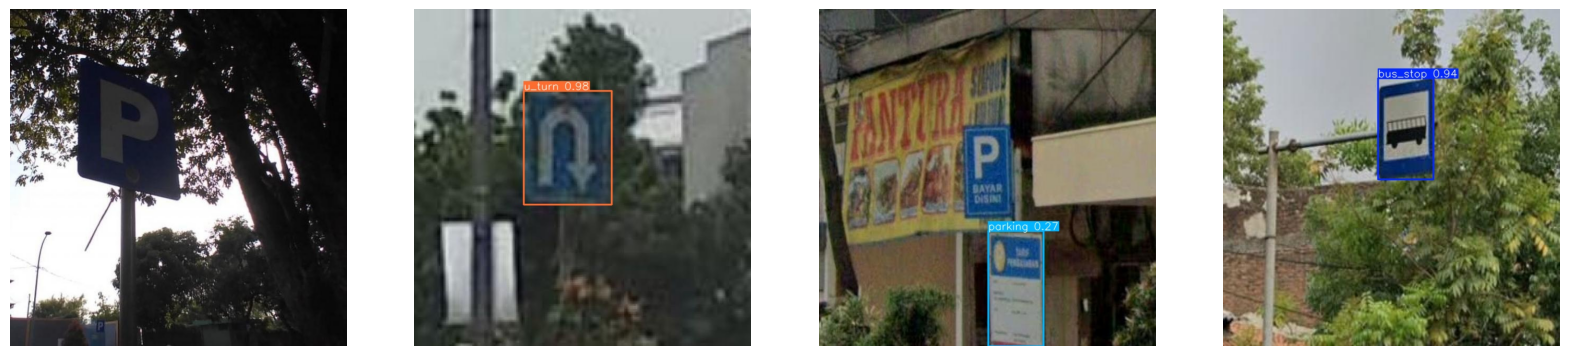

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

prediction_images = glob.glob("/content/runs/detect/predict/*.jpg")

plt.figure(figsize=(20, 10))
for i, img_path in enumerate(prediction_images[:4]):
    plt.subplot(1, 4, i + 1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis("off")
plt.show()

## **Задание 3. Сформируйте свой датасет для детекции объектов и обучите на нем модель YOLOv26**



Требования к датасету:

- Количество изображений в датасете: минимум 90
- Количество классов: более 2х
- Обязательно должны присутствовать изображения, содержащие несколько классов одновременно


*Примечание: Формирование датасета включает в себя поиск изображений и ручное аннотирование объектов на изображениях.*

In [14]:
from roboflow import Roboflow
rf = Roboflow(api_key="s8Qhfa9A2CEy9tSkjMOH")
project = rf.workspace("rmyobjdetect").project("myobjdetection-4lrvb")
version = project.version(4)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to MyObjDetection-4 in yolo26:: 100%|██████████| 435/435 [00:00<00:00, 2547.87it/s]


In [21]:
!yolo train model=yolo26n.pt data={dataset.location}/data.yaml epochs=5 imgsz=640

New https://pypi.org/project/ultralytics/8.4.65 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/MyObjDetection-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

In [22]:
!yolo predict model=/content/runs/detect/train-2/weights/best.pt source={dataset.location}/test/images conf=0.25

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs

image 1/9 /content/MyObjDetection-4/test/images/2_jpeg.rf.dc6afc24cc195f4b0105c5194b1bf8db.jpg: 640x640 (no detections), 11.8ms
image 2/9 /content/MyObjDetection-4/test/images/49_jpeg.rf.01fc7a559c8153d7d99edfd1128ee73f.jpg: 640x640 1 chicken, 12.0ms
image 3/9 /content/MyObjDetection-4/test/images/56_jpeg.rf.a5b1fa44e56e49ec81a561524ec7b93d.jpg: 640x640 1 cat, 12.2ms
image 4/9 /content/MyObjDetection-4/test/images/59_jpeg.rf.493e9cbbb436eb08d0b3dacb6c72fa82.jpg: 640x640 2 cats, 11.6ms
image 5/9 /content/MyObjDetection-4/test/images/5_jpeg.rf.da3152954fef1dbc8f8e9cec7d9d5c85.jpg: 640x640 1 chicken, 12.0ms
image 6/9 /content/MyObjDetection-4/test/images/6_jpeg.rf.a81bf6afcfefede13ca0341589722f96.jpg: 640x640 1 cat, 17.7ms
image 7/9 /content/MyObjDetection-4/test/images/OIF-e2bexWrojgtQnAPPcUfOWQ_jpeg.rf.442cb443d032fd939dfb

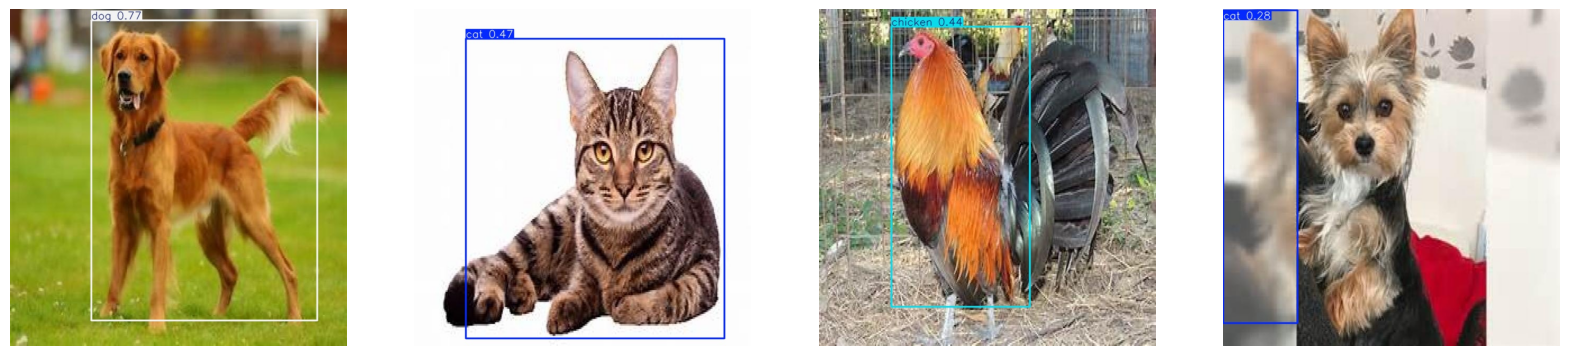

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

prediction_images = glob.glob("/content/runs/detect/predict-3/*.jpg")

plt.figure(figsize=(20, 10))
for i, img_path in enumerate(prediction_images[:4]):
    plt.subplot(1, 4, i + 1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis("off")
plt.show()

## **Задание 4 (для магистрантов). Обучите модель YOLOv26 на датасете [RSD-GOD](https://github.com/Dr-Zhuang/geospatial-object-detection). Затем самостоятельно сформируйте тестовые данные (не менее 50 изображений с аннотациями) и оцените качество обученной модели:**



**Прямая ссылка на загрузку датасета: [загрузить](https://drive.google.com/open?id=1ttvSta0BRxW7tTV_st89vSb_obHVre34)**

**Ссылка на датасет в среде roboflow universe:** https://universe.roboflow.com/animals-sqrdn/rsd-god

 *Примечание: для поиска данных удобно использовать сервис Google Earth/Google Earth Engine*

In [24]:
from roboflow import Roboflow
rf = Roboflow(api_key="s8Qhfa9A2CEy9tSkjMOH")
project = rf.workspace("animals-sqrdn").project("rsd-god")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to RSD-GOD-1 in yolo26:: 100%|██████████| 19685/19685 [00:03<00:00, 5913.82it/s] 


In [26]:
!yolo train model=yolo26n.pt data={dataset.location}/data.yaml epochs=10 imgsz=640

New https://pypi.org/project/ultralytics/8.4.65 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RSD-GOD-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tr

In [ ]:
!yolo predict model=/content/runs/detect/train-6/weights/best.pt source={dataset.location}/test/images conf=0.25

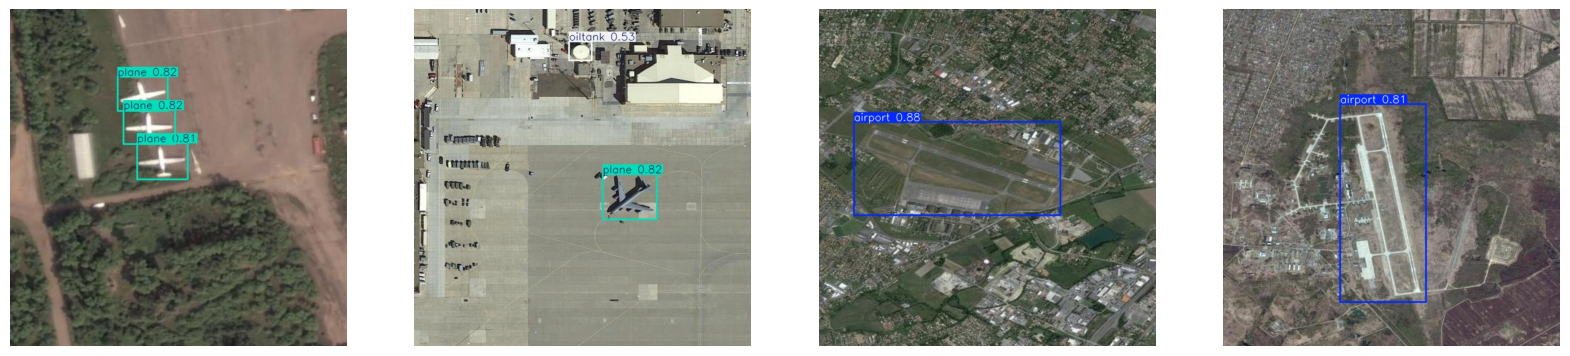

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

prediction_images = glob.glob("/content/runs/detect/predict-4/*.jpg")

plt.figure(figsize=(20, 10))
for i, img_path in enumerate(prediction_images[:4]):
    plt.subplot(1, 4, i + 1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis("off")
plt.show()